# Cats vs Dogs Image Classification (Task 1)
Binary classifier: **0 = Cat, 1 = Dog**, using TensorFlow/Keras, a memory-efficient `tf.data` pipeline and MobileNetV2 transfer learning.

**How to use:** run the cells from top to bottom with **Shift + Enter** (or *Kernel → Restart & Run All*). Keep this notebook in `notebooks/` and your images in `data/train/`.

## Section 1 — Install dependencies
- **What:** install the libraries we need.
- **Why:** so every import later works.
- **Code does:** runs `pip install` inside the notebook.
- **Expect:** pip messages. If it installed something new, use *Kernel → Restart* once, then continue.

In [5]:
!pip install tensorflow numpy pandas matplotlib pillow scikit-learn

## Section 2 — Import libraries and settings
- **What:** import libraries and fix the settings (`SEED`, `IMG_SIZE`, `BATCH_SIZE`).
- **Why:** a fixed seed makes results repeatable; one place for settings avoids mistakes.
- **Code does:** imports everything and seeds Python, NumPy and TensorFlow.
- **Expect:** the library versions printed.

In [1]:
# ===== CODE CELL 2 =====
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

# Clear error if TensorFlow is missing
try:
    import tensorflow as tf
except ImportError:
    raise ImportError("TensorFlow is not installed. Run the install cell (Section 1), "
                      "then restart the kernel: Kernel -> Restart.")

# ---------------- Settings used everywhere ----------------
SEED = 42
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 5
AUTOTUNE = tf.data.AUTOTUNE
CLASS_NAMES = ["Cat", "Dog"]      # index 0 = Cat, index 1 = Dog

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__, "| Pandas:", pd.__version__, "| scikit-learn:", sklearn.__version__)

TensorFlow: 2.22.0-rc0
NumPy: 2.4.6 | Pandas: 3.0.3 | scikit-learn: 1.9.1


## Section 3 — Project paths
- **What:** find the dataset, models and results folders.
- **Why:** the notebook should work whether Jupyter was opened in `notebooks/` or in the project root.
- **Code does:** checks the current folder and its parent for `data/train`, then creates `models/` and `results/` if missing.
- **Expect:** the detected folder paths.

In [2]:
# ===== CODE CELL 3 =====
def find_project_root():
    # Works if Jupyter runs from project/notebooks/ (uses ../data/train)
    # or from project/ (uses data/train).
    cwd = Path.cwd().resolve()
    for candidate in [cwd, cwd.parent]:
        if (candidate / "data" / "train").is_dir():
            return candidate
    # Not found: guess based on the current folder name (error is raised in the next section)
    return cwd.parent if cwd.name == "notebooks" else cwd

PROJECT_ROOT = find_project_root()
train_dir = PROJECT_ROOT / "data" / "train"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
PRED_DIR = RESULTS_DIR / "predictions"
MODEL_PATH = MODELS_DIR / "cats_vs_dogs_mobilenetv2.keras"

for folder in [MODELS_DIR, RESULTS_DIR, PRED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Current folder :", Path.cwd())
print("Project root   :", PROJECT_ROOT)
print("Dataset folder :", train_dir)

Current folder : C:\Users\vijay\Downloads\New folder\Machine-Learning\notebooks
Project root   : C:\Users\vijay\Downloads\New folder\Machine-Learning
Dataset folder : C:\Users\vijay\Downloads\New folder\Machine-Learning\data\train


## Section 4 — Load the dataset into a DataFrame
- **What:** list all image files and infer labels from filenames.
- **Why:** the images are not in `cat/` and `dog/` folders, so the *filename* is our label (`cat.*` → 0, `dog.*` → 1).
- **Code does:** scans `data/train`, builds a DataFrame with `filepath`, `label`, `class_name`, and stops with a clear message if something is wrong.
- **Expect:** about 25,000 images (12,500 cats + 12,500 dogs) and the first 5 rows.

In [3]:
# ===== CODE CELL 4 =====
# ---- Safety checks with clear messages ----
if not train_dir.is_dir():
    raise FileNotFoundError(f"Dataset folder not found: {train_dir}\n"
                            "Put your images in data/train/ (cat.0.jpg, dog.0.jpg, ...) "
                            "and make sure this notebook is inside the notebooks/ folder.")

rows = []
for p in sorted(train_dir.iterdir()):
    if not p.is_file() or p.suffix.lower() not in (".jpg", ".jpeg"):
        continue                                   # ignore non-image files
    name = p.name.lower()
    if name.startswith("cat"):
        rows.append((str(p), 0, "Cat"))
    elif name.startswith("dog"):
        rows.append((str(p), 1, "Dog"))            # files not starting with cat/dog are ignored

df = pd.DataFrame(rows, columns=["filepath", "label", "class_name"])

if df.empty:
    raise ValueError("No images found. Files must be .jpg and named like cat.0.jpg / dog.0.jpg.")
if (df["label"] == 0).sum() == 0:
    raise ValueError("No cat images found. Cat files must start with 'cat'.")
if (df["label"] == 1).sum() == 0:
    raise ValueError("No dog images found. Dog files must start with 'dog'.")

print("Total images:", len(df))
print("Number of cats:", (df["label"] == 0).sum())
print("Number of dogs:", (df["label"] == 1).sum())
df.head()

Total images: 25000
Number of cats: 12500
Number of dogs: 12500


,filepath,label,class_name
0,C:\Users\vijay\Downloads\New folder\Machine-Le...,0,Cat
1,C:\Users\vijay\Downloads\New folder\Machine-Le...,0,Cat
2,C:\Users\vijay\Downloads\New folder\Machine-Le...,0,Cat
3,C:\Users\vijay\Downloads\New folder\Machine-Le...,0,Cat
4,C:\Users\vijay\Downloads\New folder\Machine-Le...,0,Cat


## Section 5 — Check for corrupt images (safety step)
- **What:** try to open every image once.
- **Why:** one broken file would crash training after many minutes.
- **Code does:** verifies each file with Pillow (one image at a time, so it does not use much RAM) and removes unreadable ones.
- **Expect:** "No corrupt images found" (this takes about a minute for 25,000 images).

In [4]:
# ===== CODE CELL 5 =====
bad_files = []
for fp in df["filepath"]:
    try:
        with Image.open(fp) as im:
            im.verify()
    except Exception:
        bad_files.append(fp)

if bad_files:
    print(f"Removing {len(bad_files)} corrupt image(s):", bad_files[:5])
    df = df[~df["filepath"].isin(bad_files)].reset_index(drop=True)
else:
    print("No corrupt images found.")
print("Images kept:", len(df))

No corrupt images found.
Images kept: 25000


## Section 6 — Dataset exploration
- **What:** count the images per class and plot the class distribution.
- **Why:** if one class were much bigger, accuracy alone could be misleading.
- **Code does:** counts cats/dogs and saves a bar chart to `results/class_distribution.png`.
- **Expect:** a bar chart with two nearly equal bars.

Number of images: 25000
Number of cats  : 12500
Number of dogs  : 12500

Class distribution:
class_name
Cat    50.0 %
Dog    50.0 %
Name: count, dtype: str


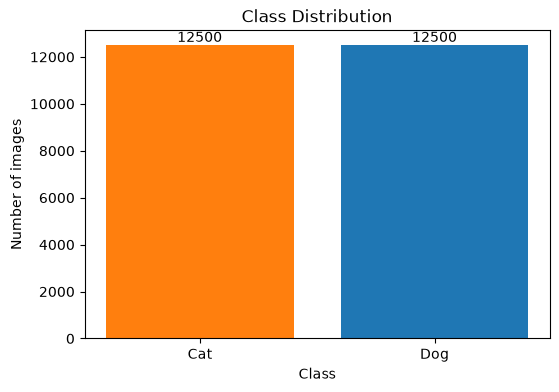

In [5]:
# ===== CODE CELL 6 =====
counts = df["class_name"].value_counts().reindex(CLASS_NAMES)
print("Number of images:", len(df))
print("Number of cats  :", counts["Cat"])
print("Number of dogs  :", counts["Dog"])
print("\nClass distribution:")
print((counts / len(df) * 100).round(2).astype(str) + " %")

plt.figure(figsize=(6, 4))
bars = plt.bar(CLASS_NAMES, counts.values, color=["tab:orange", "tab:blue"])
plt.bar_label(bars)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.savefig(RESULTS_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 7 — Visualize sample images
- **What:** show 8 random images (4 cats, 4 dogs).
- **Why:** to confirm that labels match the pictures.
- **Code does:** samples rows from the DataFrame, opens them with Pillow, saves `results/sample_images.png`.
- **Expect:** a 2×4 grid titled "Cat" or "Dog".

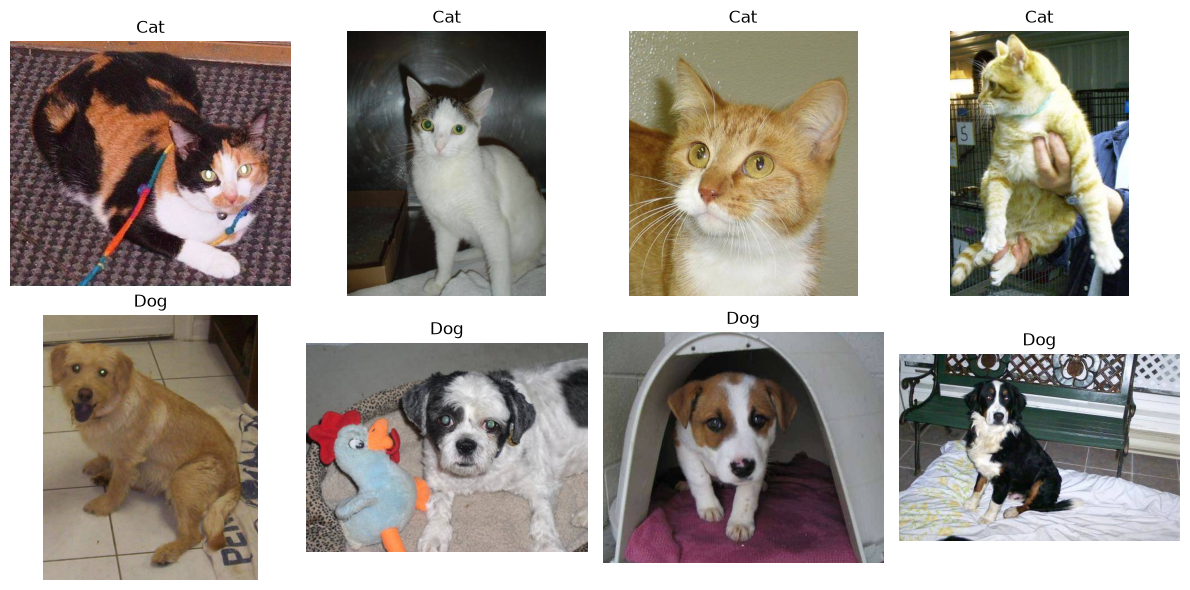

In [6]:
# ===== CODE CELL 7 =====
samples = pd.concat([
    df[df["label"] == 0].sample(4, random_state=SEED),
    df[df["label"] == 1].sample(4, random_state=SEED),
])

plt.figure(figsize=(12, 6))
for i, (_, row) in enumerate(samples.iterrows()):
    plt.subplot(2, 4, i + 1)
    plt.imshow(Image.open(row["filepath"]).convert("RGB"))
    plt.title(row["class_name"])
    plt.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 8 — Train/validation split
- **What:** split the file list into 80% training and 20% validation.
- **Why:** the model must be tested on images it never trained on.
- **Code does:** `train_test_split` with `stratify` keeps the cat/dog ratio equal in both parts. We split only the *DataFrame* (paths), never big image arrays.
- **Expect:** about 20,000 training and 5,000 validation images with balanced classes.

In [7]:
# ===== CODE CELL 8 =====
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"],
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training samples  :", len(train_df))
print("Validation samples:", len(val_df))
print("\nTraining class distribution:\n", train_df["class_name"].value_counts())
print("\nValidation class distribution:\n", val_df["class_name"].value_counts())

Training samples  : 20000
Validation samples: 5000

Training class distribution:
 class_name
Dog    10000
Cat    10000
Name: count, dtype: int64

Validation class distribution:
 class_name
Dog    2500
Cat    2500
Name: count, dtype: int64


## Section 9 — Memory-efficient image loader
- **What:** a function that turns *one file path* into *one ready image*.
- **Why:** loading 25,000 images into RAM at once is slow and can crash your computer. TensorFlow will call this function on the fly, batch by batch.
- **Code does:** read file → decode JPEG (RGB) → resize to 128×128 → float32 → scale pixels to 0–1.
- **Expect:** no output (we test it in the next section).

In [8]:
# ===== CODE CELL 9 =====
def load_image(filepath, label):
    image_bytes = tf.io.read_file(filepath)                 # 1. read the file
    image = tf.image.decode_jpeg(image_bytes, channels=3)   # 2-3. decode JPEG, force RGB (3 channels)
    image = tf.image.resize(image, IMG_SIZE)                # 4. resize to 128x128
    image = tf.cast(image, tf.float32) / 255.0              # 5-6. float32, normalize to 0-1
    return image, label                                     # 7. return (image, label)

## Section 10 — Build the tf.data pipelines
- **What:** create `train_ds` and `val_ds`.
- **Why:** the pipeline is *paths + labels → load → batch → prefetch → model*. While the model trains on one batch, the next batch is already being prepared.
- **Code does:** builds datasets from the DataFrames. Only training data is shuffled. `AUTOTUNE` lets TensorFlow pick the parallelism. Then it pulls one batch to test.
- **Expect:** image shape `(32, 128, 128, 3)`, labels shape `(32,)`, pixel range within 0.0 – 1.0.

In [9]:
# ===== CODE CELL 10 =====
def make_dataset(dataframe, training):
    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe["filepath"].values, dataframe["label"].values.astype("float32"))
    )
    if training:
        ds = ds.shuffle(1000, seed=SEED)                    # shuffle training data only
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)    # load images in parallel
    ds = ds.batch(BATCH_SIZE)                               # groups of 32
    ds = ds.prefetch(AUTOTUNE)                              # prepare next batch in advance
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)

# Test one batch
images, labels = next(iter(train_ds))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Pixel range :", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Images shape: (32, 128, 128, 3)
Labels shape: (32,)
Pixel range : 0.0 to 1.0


## Section 11 — Visualize one batch
- **What:** show 8 images from the batch we just loaded.
- **Why:** to check the pipeline (resizing, colors, labels) works.
- **Code does:** plots the first 8 images with titles Cat/Dog from the labels.
- **Expect:** 8 small (128×128) pictures with correct titles.

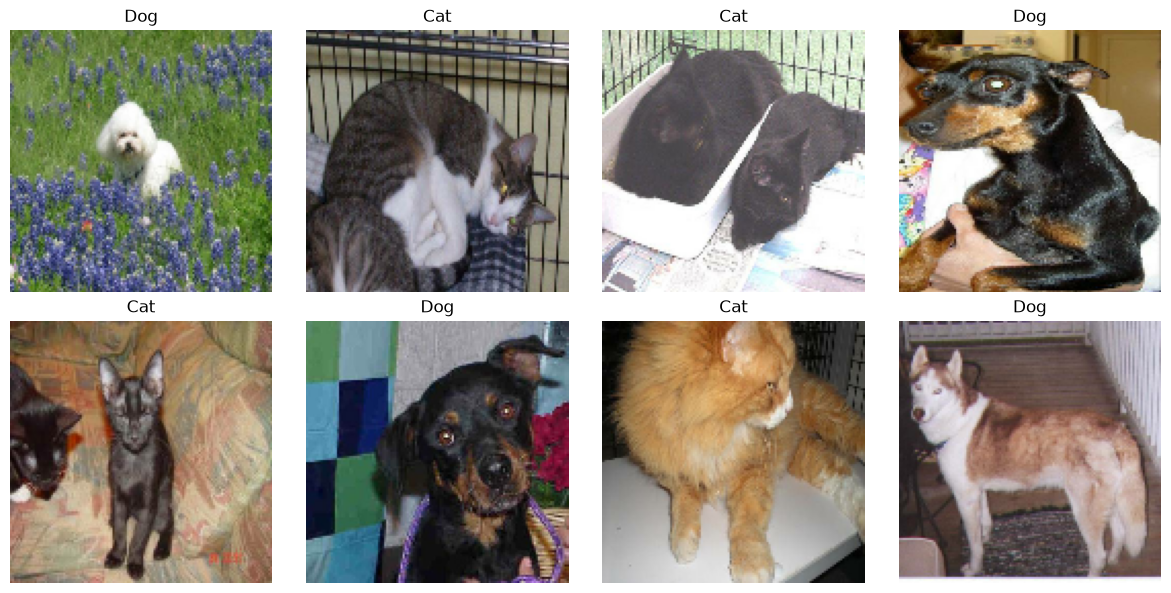

In [10]:
# ===== CODE CELL 11 =====
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(CLASS_NAMES[int(labels[i].numpy())])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Section 12 — Data augmentation
- **What:** random flips, small rotations and zooms.
- **Why:** it shows the model slightly different versions of each picture, so it learns general "cat-ness" and "dog-ness" instead of memorizing photos. This helps it **generalize**.
- **Code does:** defines the augmentation layers. They will be the first layers inside the model, and Keras turns them **on only during training** (validation and prediction are never augmented).
- **Expect:** a preview of one image with 4 augmented versions.

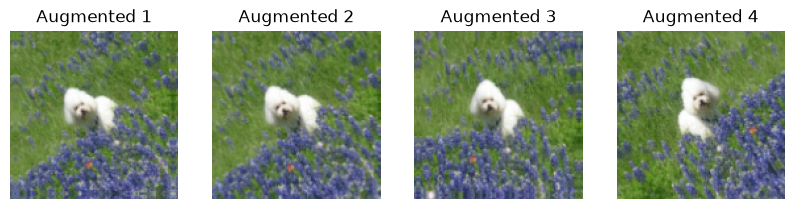

In [11]:
# ===== CODE CELL 12 =====
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

# Preview: the same image augmented 4 times (training=True forces augmentation on)
plt.figure(figsize=(10, 3))
for i in range(4):
    aug = data_augmentation(tf.expand_dims(images[0], 0), training=True)
    plt.subplot(1, 4, i + 1)
    plt.imshow(aug[0].numpy().clip(0, 1))
    plt.title(f"Augmented {i + 1}")
    plt.axis("off")
plt.show()

## Section 13 — Build the model (MobileNetV2 transfer learning)
- **What:** a CNN that already learned to "see" from millions of ImageNet photos.
- **Why:** reusing it gives high accuracy quickly, even on a normal laptop.
- **Code does:** builds `Input → Augmentation → Rescaling → MobileNetV2 (frozen) → GlobalAveragePooling → Dropout → Dense(1, sigmoid)`. The output is the probability of **Dog** (≥ 0.5 means Dog). The `Rescaling` layer converts our 0–1 pixels to the −1…1 range MobileNetV2 was trained with.
- **Expect:** a download of ImageNet weights on first run (needs internet). If the download fails, the notebook warns you and uses random weights.

In [ ]:
# ===== CODE CELL 13 =====
PRETRAINED = True
try:
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(128, 128, 3),
        include_top=False,
        weights="imagenet",
    )
except Exception as e:
    print("WARNING: could not load ImageNet weights:", e)
    print("Using randomly initialised weights instead (accuracy will be lower).")
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(128, 128, 3), include_top=False, weights=None)
    PRETRAINED = False

base_model.trainable = not PRETRAINED     # freeze the pretrained base initially

inputs = tf.keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)                                   # only active in training
x = tf.keras.layers.Rescaling(scale=2.0, offset=-1.0)(x)        # 0..1  ->  -1..1
x = base_model(x, training=False)                               # keep BatchNorm in inference mode
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
model = tf.keras.Model(inputs, outputs, name="cats_vs_dogs_mobilenetv2")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
print("Pretrained ImageNet weights used:", PRETRAINED)

## Section 14 — Model summary
- **What:** print the layers and parameter counts.
- **Why:** to understand the architecture and see how few parameters are trainable.
- **Code does:** `model.summary()`.
- **Expect:** a table. *Trainable params* should be small (about 1,281, the final Dense layer) because MobileNetV2 is frozen. Its ~2.2 million weights are reused, not retrained.

In [ ]:
# ===== CODE CELL 14 =====
model.summary()

## Section 15 — Train the model
- **What:** train the new classifier head for up to 5 epochs.
- **Why:** the head learns to turn MobileNetV2's features into "cat or dog".
- **Code does:** `model.fit` with `EarlyStopping`, which stops if validation loss does not improve for 2 epochs and restores the best weights.
- **Expect:** per-epoch loss/accuracy lines. This can take several minutes on a CPU, so be patient. Validation accuracy is usually already high after epoch 1.

In [ ]:
# ===== CODE CELL 15 =====
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
)

## Section 16 — Optional fine-tuning
- **What:** carefully "unfreeze" the last ~20 layers of MobileNetV2 and train a little more with a very small learning rate (1e-5).
- **Why:** it can adapt the deepest features to cats and dogs and gain a bit more accuracy.
- **Code does:** fine-tunes for up to 3 epochs. **Fallback:** the original frozen-model weights are saved first. If fine-tuning fails, or does not improve validation loss, they are restored automatically.
- **Expect:** a few more epochs and a message telling you whether fine-tuning was kept. Slower than Section 15. If it takes too long, set `FINE_TUNE_EPOCHS = 0`.

In [ ]:
# ===== CODE CELL 16 =====
FINE_TUNE_EPOCHS = 3       # set to 0 to skip fine-tuning
FINE_TUNE_LAYERS = 20      # number of final base-model layers to unfreeze

fine_tune_history = None
if PRETRAINED and FINE_TUNE_EPOCHS > 0:
    stage1_best_val_loss = min(history.history["val_loss"])
    weights_before_finetune = model.get_weights()          # fallback copy (best frozen model)
    try:
        base_model.trainable = True
        for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
            layer.trainable = False                        # keep everything except the last ~20 layers frozen

        model.compile(                                     # re-compile after changing trainable flags
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss="binary_crossentropy",
            metrics=["accuracy"],
        )
        early_stop_ft = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=2, restore_best_weights=True)

        fine_tune_history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=FINE_TUNE_EPOCHS,
            callbacks=[early_stop_ft],
        )

        if min(fine_tune_history.history["val_loss"]) > stage1_best_val_loss:
            print("\nFine-tuning did not improve validation loss -> restoring the original frozen model.")
            model.set_weights(weights_before_finetune)
            fine_tune_history = None
        else:
            print("\nFine-tuning improved validation loss -> keeping the fine-tuned model.")
    except Exception as e:
        print("\nFine-tuning failed:", e)
        print("Fallback: restoring the original frozen model.")
        model.set_weights(weights_before_finetune)
        fine_tune_history = None
else:
    print("Fine-tuning skipped.")

## Section 17 — Training graphs
- **What:** plot accuracy and loss for training vs validation.
- **Why:** to see whether the model is learning and whether it overfits (training much better than validation).
- **Code does:** joins the histories of both training stages and saves two separate figures.
- **Expect:** two plots (`results/training_accuracy.png`, `results/training_loss.png`). A dashed line marks where fine-tuning began (if it was kept).

In [ ]:
# ===== CODE CELL 17 =====
acc = list(history.history["accuracy"])
val_acc = list(history.history["val_accuracy"])
loss = list(history.history["loss"])
val_loss_hist = list(history.history["val_loss"])
split_epoch = None

if fine_tune_history is not None:
    split_epoch = len(acc)
    acc += fine_tune_history.history["accuracy"]
    val_acc += fine_tune_history.history["val_accuracy"]
    loss += fine_tune_history.history["loss"]
    val_loss_hist += fine_tune_history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

# ---- Accuracy ----
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, marker="o", label="Training Accuracy")
plt.plot(epochs_range, val_acc, marker="o", label="Validation Accuracy")
if split_epoch:
    plt.axvline(split_epoch, color="gray", linestyle="--", label="Fine-tuning starts")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(RESULTS_DIR / "training_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, marker="o", label="Training Loss")
plt.plot(epochs_range, val_loss_hist, marker="o", label="Validation Loss")
if split_epoch:
    plt.axvline(split_epoch, color="gray", linestyle="--", label="Fine-tuning starts")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(RESULTS_DIR / "training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 18 — Evaluation
- **What:** measure the final model on the validation set.
- **Why:** these numbers show how well it works on unseen images.
- **Code does:** predicts a probability for every validation image, turns it into 0/1 with `>= 0.5`, computes accuracy, precision, recall, F1 (Dog is the "positive" class) and saves `results/metrics.json` and `results/metrics.txt`.
- **Expect:** four metrics and a per-class report. All numbers come from the real run.

In [ ]:
# ===== CODE CELL 18 =====
val_loss, val_accuracy_keras = model.evaluate(val_ds, verbose=0)

# val_ds is not shuffled, so predictions are in the same order as val_df
y_prob = model.predict(val_ds, verbose=0).ravel()          # probability of Dog
y_true = val_df["label"].values.astype(int)
y_pred = (y_prob >= 0.5).astype(int)                       # >= 0.5 -> Dog (1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)

print(f"Validation loss: {val_loss:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}\n")
print(report)

metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "val_loss": float(val_loss),
    "total_images": int(len(df)),
    "training_samples": int(len(train_df)),
    "validation_samples": int(len(val_df)),
}
with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)
with open(RESULTS_DIR / "metrics.txt", "w") as f:
    for key, value in metrics.items():
        f.write(f"{key}: {value}\n")
    f.write("\nClassification report\n" + report)
print("Saved metrics.json and metrics.txt")

## Section 19 — Confusion matrix
- **What:** a table of actual vs predicted classes.
- **Why:** it shows *which* mistakes happen (cats called dogs, or dogs called cats).
- **Code does:** `confusion_matrix` + `ConfusionMatrixDisplay`, saved as `results/confusion_matrix.png`.
- **Expect:** a 2×2 heatmap. Rows = Actual, columns = Predicted. The diagonal holds the correct predictions.

In [ ]:
# ===== CODE CELL 19 =====
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (rows = Actual [Cat, Dog], columns = Predicted [Cat, Dog]):\n", cm)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_xlabel("Predicted label (Predicted Cat / Predicted Dog)")
ax.set_ylabel("Actual label (Actual Cat / Actual Dog)")
ax.set_title("Confusion Matrix (Validation Set)")
fig.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 20 — 12 sample predictions
- **What:** predict 12 random validation images and show the results.
- **Why:** to see the model's behaviour and confidence on real examples.
- **Code does:** loads 12 images with the same `load_image` function, predicts, draws a 3×4 grid (green title = correct, red = wrong), saves `predictions.png` and `predictions.csv`.
- **Expect:** each title shows Actual, Predicted and Confidence.

In [ ]:
# ===== CODE CELL 20 =====
N_SAMPLES = 12
sample_df = val_df.sample(n=N_SAMPLES, random_state=SEED).reset_index(drop=True)

sample_images = np.stack([load_image(fp, 0.0)[0].numpy() for fp in sample_df["filepath"]])
sample_prob_dog = model.predict(sample_images, verbose=0).ravel()

records = []
plt.figure(figsize=(14, 10))
for i, row in sample_df.iterrows():
    prob_dog = float(sample_prob_dog[i])
    pred_label = 1 if prob_dog >= 0.5 else 0
    confidence = prob_dog if pred_label == 1 else 1 - prob_dog
    actual_name = CLASS_NAMES[int(row["label"])]
    pred_name = CLASS_NAMES[pred_label]

    records.append({
        "image": os.path.basename(row["filepath"]),
        "actual": actual_name,
        "predicted": pred_name,
        "confidence": round(confidence * 100, 2),
    })

    plt.subplot(3, 4, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f"Actual: {actual_name}\nPredicted: {pred_name}\nConfidence: {confidence * 100:.1f}%",
              color="green" if actual_name == pred_name else "red", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.savefig(PRED_DIR / "predictions.png", dpi=150, bbox_inches="tight")
plt.show()

predictions_df = pd.DataFrame(records, columns=["image", "actual", "predicted", "confidence"])
predictions_df.to_csv(PRED_DIR / "predictions.csv", index=False)
predictions_df

## Section 21 — Predict a single image
- **What:** a reusable function `predict_image(path)`.
- **Why:** this is how you would use the model on any new photo.
- **Code does:** load → RGB → resize 128×128 → normalize → predict → show the picture and print the result.
- **Expect:** e.g. `Prediction: Dog` and `Confidence: 94.20%` (your numbers will differ).

In [ ]:
# ===== CODE CELL 21 =====
def predict_image(image_path, model_to_use=None, show=True):
    if model_to_use is None:
        model_to_use = model                                   # default: the model trained above
    image_path = Path(image_path)
    if not image_path.is_file():
        raise FileNotFoundError(f"Image not found: {image_path}")

    img = Image.open(image_path).convert("RGB")                # 1-2. load, convert to RGB
    arr = np.asarray(img.resize(IMG_SIZE), dtype="float32")    # 3. resize to 128x128
    arr = arr / 255.0                                          # 4. normalize to 0-1
    batch = np.expand_dims(arr, axis=0)                        # shape (1, 128, 128, 3)

    prob_dog = float(model_to_use.predict(batch, verbose=0)[0][0])   # 5. run the model
    label = "Dog" if prob_dog >= 0.5 else "Cat"                # 6. Cat / Dog
    confidence = prob_dog if label == "Dog" else 1 - prob_dog  # 7. confidence

    if show:                                                   # 8. display
        plt.imshow(img)
        plt.title(f"{label} ({confidence * 100:.1f}%)")
        plt.axis("off")
        plt.show()
    print(f"Prediction: {label}")                              # 9. print result
    print(f"Confidence: {confidence * 100:.2f}%")
    return label, confidence

# Try it on one validation image (replace with any image path you like)
example_path = val_df.loc[0, "filepath"]
print("Actual class:", val_df.loc[0, "class_name"])
_ = predict_image(example_path)

## Section 22 — Save the model
- **What:** save the trained model to `models/cats_vs_dogs_mobilenetv2.keras`.
- **Why:** so you can use it later without retraining.
- **Code does:** `model.save(...)`.
- **Expect:** a confirmation with the file size.

In [ ]:
# ===== CODE CELL 22 =====
model.save(MODEL_PATH)
print("Model saved to:", MODEL_PATH)
print(f"File size: {MODEL_PATH.stat().st_size / (1024 * 1024):.1f} MB")

## Section 23 — Load and test the saved model
- **What:** load the saved file and predict with it.
- **Why:** to prove the saved model works on its own.
- **Code does:** checks the file exists, loads it with `tf.keras.models.load_model`, predicts the same image and compares with the original model.
- **Expect:** the same prediction as Section 21 and "Saved model works correctly".

In [ ]:
# ===== CODE CELL 23 =====
if not MODEL_PATH.is_file():
    raise FileNotFoundError(f"Model file missing: {MODEL_PATH}\nRun the training and save cells first.")

loaded_model = tf.keras.models.load_model(MODEL_PATH)
label, conf = predict_image(example_path, model_to_use=loaded_model)

# Compare with the in-memory model
original_p = float(model.predict(np.expand_dims(load_image(example_path, 0.0)[0].numpy(), 0), verbose=0)[0][0])
loaded_p = float(loaded_model.predict(np.expand_dims(load_image(example_path, 0.0)[0].numpy(), 0), verbose=0)[0][0])
print(f"Probability of Dog -> original: {original_p:.4f} | loaded: {loaded_p:.4f}")
print("Saved model works correctly." if abs(original_p - loaded_p) < 1e-4 else "Warning: predictions differ.")

## Section 24 — Final results summary
- **What:** print a summary of the whole project.
- **Why:** a quick overview for your submission.
- **Code does:** prints values taken from the variables computed above. Nothing is typed in by hand.
- **Expect:** the final results block.

In [ ]:
# ===== CODE CELL 24 =====
print("=" * 40)
print("FINAL RESULTS")
print("=" * 40)
print(f"\nDataset size: {len(df)}")
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nModel: MobileNetV2 Transfer Learning"
      + (" (with fine-tuning)" if fine_tune_history is not None else " (frozen base)"))
print(f"Image size: {IMG_SIZE[0]}x{IMG_SIZE[1]}")
print(f"Batch size: {BATCH_SIZE}")
print("\nModel saved to:")
print(f"models/{MODEL_PATH.name}")